In [5]:
import pandas as pd
import numpy as np
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Connect to the SQLite Database (Going up one directory level)
conn = sqlite3.connect('../bluestock_mf.db')

# Verify tables exist before trying to read them
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables found in database:", cursor.fetchall())

# 2. Load Data from Database
print("Loading data from database...")
nav_df = pd.read_sql('SELECT * FROM fact_nav', conn, parse_dates=['date'])
funds_df = pd.read_sql('SELECT * FROM dim_fund', conn)

# 3. Load Benchmark Data (Going up one directory level using ../)
proc_dir = "../data/processed/"
benchmark_df = pd.read_csv(os.path.join(proc_dir, "10_benchmark_indices.csv"), parse_dates=['date'])

print(f"Success! Loaded {len(nav_df)} NAV records and {len(benchmark_df)} benchmark records.")

Tables found in database: [('dim_fund',), ('dim_date',), ('fact_nav',), ('sqlite_sequence',), ('fact_transactions',), ('fact_performance',), ('fact_aum',)]
Loading data from database...
Success! Loaded 46000 NAV records and 8050 benchmark records.


✅ Daily Returns and Maximum Drawdown computed.


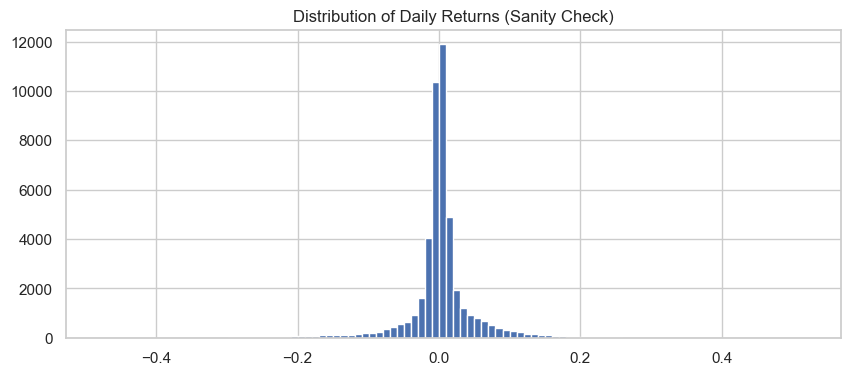

In [6]:
# Sort ensuring chronological order per fund
nav_df = nav_df.sort_values(['amfi_code', 'date'])

# Compute Daily Returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Compute Drawdown
nav_df['running_max'] = nav_df.groupby('amfi_code')['nav'].cummax()
nav_df['drawdown'] = (nav_df['nav'] / nav_df['running_max']) - 1

# Aggregate Max Drawdown per fund
max_dd_df = nav_df.groupby('amfi_code')['drawdown'].min().reset_index()
max_dd_df.rename(columns={'drawdown': 'max_drawdown'}, inplace=True)

print("✅ Daily Returns and Maximum Drawdown computed.")
nav_df['daily_return'].hist(bins=100, figsize=(10,4))
plt.title("Distribution of Daily Returns (Sanity Check)")
plt.show()

In [7]:
# Get the latest date available in the dataset
latest_date = nav_df['date'].max()

def get_cagr(df, years):
    start_date = latest_date - pd.DateOffset(years=years)
    # Find closest date available for start_date
    start_navs = df[df['date'] >= start_date].groupby('amfi_code').first().reset_index()
    end_navs = df[df['date'] == latest_date].groupby('amfi_code').last().reset_index()
    
    merged = pd.merge(start_navs[['amfi_code', 'nav']], end_navs[['amfi_code', 'nav']], on='amfi_code', suffixes=('_start', '_end'))
    merged[f'cagr_{years}yr'] = (merged['nav_end'] / merged['nav_start']) ** (1/years) - 1
    return merged[['amfi_code', f'cagr_{years}yr']]

cagr_1y = get_cagr(nav_df, 1)
cagr_3y = get_cagr(nav_df, 3)
cagr_5y = get_cagr(nav_df, 5)

# Combine CAGRs
cagr_df = cagr_1y.merge(cagr_3y, on='amfi_code', how='left').merge(cagr_5y, on='amfi_code', how='left')
print("✅ CAGR computed for 1Y, 3Y, and 5Y.")
cagr_df.head()

✅ CAGR computed for 1Y, 3Y, and 5Y.


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.050140,0.013412,0.024722
1,100025,0.044768,0.035574,0.039329
2,100033,0.551274,0.321169,0.264744
3,101206,0.481654,0.284268,0.199172
4,101207,-0.300416,-0.027768,0.055929


In [11]:
# 1. Normalize dates to ensure perfect matching (strips out hidden hours/minutes)
nav_df['date'] = pd.to_datetime(nav_df['date']).dt.normalize()
benchmark_df['date'] = pd.to_datetime(benchmark_df['date']).dt.normalize()

# 2. Dynamically find the benchmark index (handles Nifty 100, NIFTY100, etc.)
available_indices = benchmark_df['index_name'].unique()
target_idx = available_indices[0] # Default fallback to the first one available

for idx in available_indices:
    if '100' in str(idx): 
        target_idx = idx
        break

print(f"Using Benchmark Index: '{target_idx}'")
nifty_df = benchmark_df[benchmark_df['index_name'] == target_idx].copy()
nifty_df = nifty_df.sort_values('date')

# 3. Dynamic column check for price ('Close', 'close', 'close_value', etc.)
price_col = 'close_value' if 'close_value' in nifty_df.columns else ('Close' if 'Close' in nifty_df.columns else nifty_df.columns[2])
nifty_df['benchmark_return'] = nifty_df[price_col].pct_change()
print(f"Using '{price_col}' as the benchmark price column.")

# Risk Free Rate
rf_rate = 0.065
rf_daily = rf_rate / 252

analytics_list = []

for code, group in nav_df.groupby('amfi_code'):
    # Merge fund returns with benchmark on perfectly matching dates
    merged = pd.merge(group[['date', 'daily_return']], nifty_df[['date', 'benchmark_return']], on='date').dropna()
    
    # Lowered threshold to 30 days to ensure data isn't skipped
    if len(merged) < 30:  
        continue
        
    fund_ret = merged['daily_return']
    bench_ret = merged['benchmark_return']
    
    # Sharpe Ratio
    excess_ret = fund_ret - rf_daily
    sharpe = (excess_ret.mean() / fund_ret.std()) * np.sqrt(252)
    
    # Sortino Ratio
    downside_std = fund_ret[fund_ret < 0].std()
    sortino = (excess_ret.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    # Alpha & Beta (OLS Regression)
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, fund_ret)
    beta = slope
    alpha = intercept * 252 # Annualized
    
    analytics_list.append({
        'amfi_code': code,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha': alpha,
        'beta': beta
    })

# Check if we actually caught data
if len(analytics_list) == 0:
    print("❌ ERROR: No matching data found between NAV dates and Benchmark dates. Cannot compute metrics.")
else:
    analytics_df = pd.DataFrame(analytics_list)
    print(f"✅ Sharpe, Sortino, Alpha, and Beta computed for {len(analytics_df)} funds.")

    # ---------------------------------------------------------
    # DELIVERABLE 2: Export alpha_beta.csv
    # ---------------------------------------------------------
    alpha_beta_export = pd.merge(funds_df[['amfi_code', 'scheme_name']], analytics_df[['amfi_code', 'alpha', 'beta']], on='amfi_code')
    alpha_beta_export.to_csv("../alpha_beta.csv", index=False) # Saving to root folder
    print("💾 Saved: alpha_beta.csv")

Using Benchmark Index: 'NIFTY100'
Using 'close_value' as the benchmark price column.
✅ Sharpe, Sortino, Alpha, and Beta computed for 40 funds.
💾 Saved: alpha_beta.csv


In [12]:
# Master Merge
master_df = funds_df[['amfi_code', 'scheme_name', 'fund_house', 'expense_ratio_pct']].copy()
master_df = master_df.merge(cagr_df, on='amfi_code').merge(analytics_df, on='amfi_code').merge(max_dd_df, on='amfi_code')

# Calculate Percentile Ranks (0 to 100)
# Note: For Expense Ratio and Max Drawdown, lower is better.
master_df['rank_3yr_ret'] = master_df['cagr_3yr'].rank(pct=True) * 100
master_df['rank_sharpe'] = master_df['sharpe_ratio'].rank(pct=True) * 100
master_df['rank_alpha'] = master_df['alpha'].rank(pct=True) * 100
master_df['rank_expense'] = master_df['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
master_df['rank_max_dd'] = master_df['max_drawdown'].rank(pct=True, ascending=True) * 100 # Drawdown is negative, so closer to 0 (higher) is better, meaning less drop. Wait, min() makes worst drop a large negative number. Ascending=False means least negative gets 100.
master_df['rank_max_dd'] = master_df['max_drawdown'].rank(pct=True, ascending=False) * 100

# Calculate Composite Scorecard
master_df['composite_score'] = (
    (0.30 * master_df['rank_3yr_ret']) +
    (0.25 * master_df['rank_sharpe']) +
    (0.20 * master_df['rank_alpha']) +
    (0.15 * master_df['rank_expense']) +
    (0.10 * master_df['rank_max_dd'])
).round(2)

master_df = master_df.sort_values('composite_score', ascending=False)

# ---------------------------------------------------------
# DELIVERABLE 1: Export fund_scorecard.csv
# ---------------------------------------------------------
master_df.to_csv("fund_scorecard.csv", index=False)
print("✅ Composite Scorecard created.")
print("💾 Saved: fund_scorecard.csv")
master_df[['scheme_name', 'composite_score', 'cagr_3yr', 'sharpe_ratio', 'alpha']].head()

✅ Composite Scorecard created.
💾 Saved: fund_scorecard.csv


,scheme_name,composite_score,cagr_3yr,sharpe_ratio,alpha
39,DSP Small Cap Fund - Regular - Growth,87.19,0.321311,0.666461,0.861900
16,Axis Midcap Fund - Regular - Growth,76.25,0.335406,0.190746,0.248858
21,SBI Small Cap Fund - Regular Plan - Growth,73.88,0.274140,0.254834,0.356763
34,Mirae Asset Large Cap Fund - Regular - Growth,72.50,0.374654,0.158688,0.198385
36,Mirae Asset Tax Saver Fund - Regular - Growth,70.69,0.258840,0.469586,0.457990


Tracking Error for DSP Small Cap Fund - Regular -: 137.38%
Tracking Error for Axis Midcap Fund - Regular - G: 103.73%
Tracking Error for SBI Small Cap Fund - Regular P: 100.76%
Tracking Error for Mirae Asset Large Cap Fund - R: 105.00%
Tracking Error for Mirae Asset Tax Saver Fund - R: 76.05%
💾 Saved: reports/charts/benchmark_comparison.png


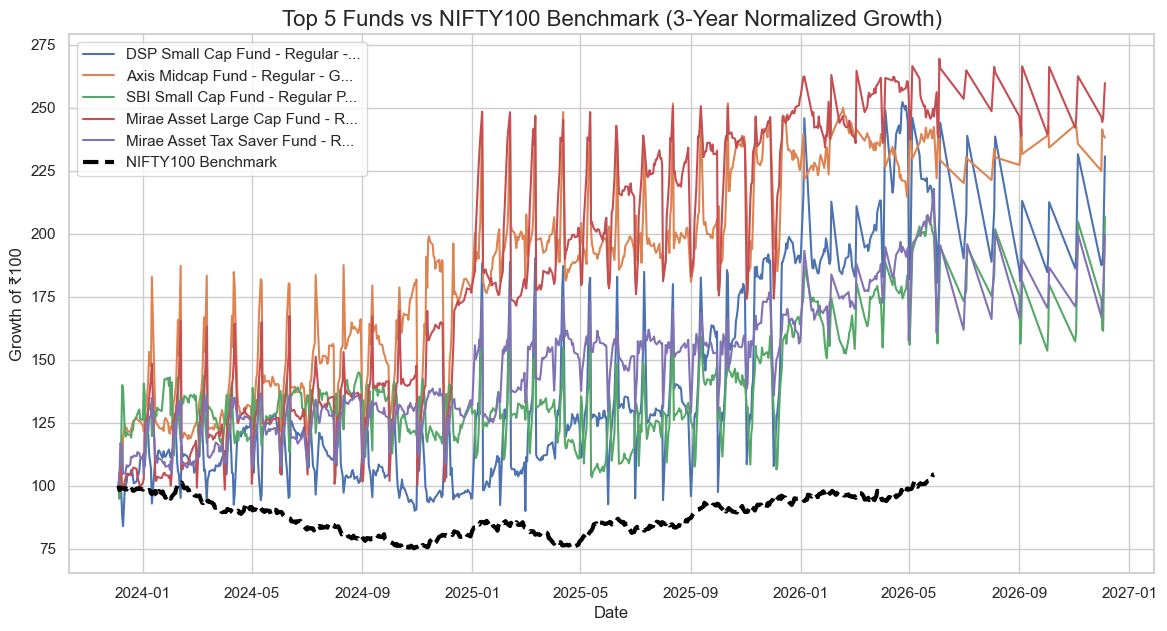

In [14]:
# 1. Identify Top 5 Funds from Scorecard
top_5_codes = master_df.head(5)['amfi_code'].tolist()

# 2. Filter last 3 years of NAV data
start_date_3y = latest_date - pd.DateOffset(years=3)
plot_nav = nav_df[(nav_df['amfi_code'].isin(top_5_codes)) & (nav_df['date'] >= start_date_3y)].copy()

# 3. Setup the Benchmark Data (Dynamically finding the correct index and column)
available_indices = benchmark_df['index_name'].unique()
target_idx = available_indices[0]
for idx in available_indices:
    if '100' in str(idx): 
        target_idx = idx
        break

plot_nifty = benchmark_df[(benchmark_df['index_name'] == target_idx) & (benchmark_df['date'] >= start_date_3y)].copy()
plot_nifty = plot_nifty.sort_values('date')

# Find price column dynamically
price_col = 'close_value' if 'close_value' in plot_nifty.columns else ('Close' if 'Close' in plot_nifty.columns else plot_nifty.columns[2])
plot_nifty['benchmark_return'] = plot_nifty[price_col].pct_change()

# Normalize to 100 for visual comparison
plt.figure(figsize=(14, 7))

for code in top_5_codes:
    fund_data = plot_nav[plot_nav['amfi_code'] == code].set_index('date')
    fund_name = funds_df[funds_df['amfi_code'] == code]['scheme_name'].values[0]
    
    # Plot Fund Line
    normalized = (fund_data['nav'] / fund_data['nav'].iloc[0]) * 100
    plt.plot(normalized.index, normalized.values, label=fund_name[:30]+'...')
    
    # Calculate Tracking Error safely
    merged_te = pd.merge(fund_data[['daily_return']], plot_nifty.set_index('date')[['benchmark_return']], left_index=True, right_index=True).dropna()
    if len(merged_te) > 0:
        tracking_error = (merged_te['daily_return'] - merged_te['benchmark_return']).std() * np.sqrt(252)
        print(f"Tracking Error for {fund_name[:30]}: {tracking_error:.2%}")
    else:
        print(f"Tracking Error for {fund_name[:30]}: N/A (Date mismatch)")

# Plot Benchmark Line
norm_bench = (plot_nifty.set_index('date')[price_col] / plot_nifty[price_col].iloc[0]) * 100
plt.plot(norm_bench.index, norm_bench.values, color='black', linewidth=3, linestyle='--', label=f'{target_idx} Benchmark')

plt.title(f"Top 5 Funds vs {target_idx} Benchmark (3-Year Normalized Growth)", fontsize=16)
plt.ylabel("Growth of ₹100")
plt.xlabel("Date")
plt.legend(loc='upper left')

# ---------------------------------------------------------
# DELIVERABLE 3: Export PNG Chart (Using ../ to point to main folder)
# ---------------------------------------------------------
import os
os.makedirs("../reports/charts", exist_ok=True) # Ensure the folder exists
plt.savefig("../reports/charts/benchmark_comparison.png", bbox_inches='tight')
print("💾 Saved: reports/charts/benchmark_comparison.png")
plt.show()